# Preprocesamiento — Punto 1: Clasificación para Focalización de Programas Sociales
**Taller 1 · Consultoría Económica con IA** | David Rodríguez · Juan Rueda · 2026

In [59]:
%matplotlib inline
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

NOTEBOOK_DIR = Path().resolve()
DIR_DATOS    = NOTEBOOK_DIR / "Datos"
DIR_VIZS     = NOTEBOOK_DIR / "Visualizaciones"
LOCAL_TRAIN  = DIR_DATOS / "train.csv"
URL_TRAIN    = (
    "https://raw.githubusercontent.com/darc-17/Sandbox_HE2_DavidRodriguez"
    "/main/Taller%201/Punto%201.%20Clasificacion%20para%20"
    "Focalizaci%C3%B3n%20de%20Programas%20Sociales/train.csv"
)

## 1. Carga de datos

In [60]:
if LOCAL_TRAIN.exists():
    df = pd.read_csv(LOCAL_TRAIN)
    print("Fuente: archivo local")
else:
    df = pd.read_csv(URL_TRAIN)
    print("Fuente: URL remota (archivo local no encontrado)")

print(f"Forma inicial: {df.shape[0]:,} obs · {df.shape[1]} variables")
print(f"Tipos de dato:\n{df.dtypes.value_counts().rename('columnas').to_string()}")

Fuente: archivo local
Forma inicial: 7,187 obs · 143 variables
Tipos de dato:
int64      130
float64      8
str          5


## 2.1 Variables redundantes

Se eliminan transformaciones SQB (cuadrados de variables ya presentes), totales de tamaño de hogar duplicados y la dummy `male` (redundante con `female`).

In [61]:
drop_redundantes = [
    # SQB — transformaciones de variables ya presentes
    "SQBescolari", "SQBage", "agesq", "SQBhogar_total",
    "SQBedjefe", "SQBhogar_nin", "SQBovercrowding",
    "SQBdependency", "SQBmeaned",
    # Tamaño del hogar — duplicados entre sí y de hogar_total
    "tamhog", "hhsize", "tamviv",
    # Subtotales por género ya calculados: r4h3 = r4h1+r4h2, etc.
    "r4h3", "r4m3", "r4t3",
    # Se conserva female
    "male",
]

drop_redundantes = [c for c in drop_redundantes if c in df.columns]
df.drop(columns=drop_redundantes, inplace=True)
print(f"Eliminadas: {len(drop_redundantes)} columnas | Shape: {df.shape}")

Eliminadas: 16 columnas | Shape: (7187, 127)


## 2.2 Imputación de valores faltantes

Cuando el missing es informativo, se crea una variable indicadora binaria antes de imputar.

In [62]:
miss_df = (
    df.isnull().sum()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
    .rename("n_missing")
    .to_frame()
    .assign(pct=lambda x: (x["n_missing"] / len(df) * 100).round(2))
)
print("Variables con missing:")
print(miss_df.to_string())

# v18q1 — NaN exclusivamente cuando v18q=0 (hogar sin tablet)
n_nan_con_tablet = df[df["v18q"] == 1]["v18q1"].isnull().sum()
n_nan_sin_tablet = df[df["v18q"] == 0]["v18q1"].isnull().sum()
print(f"\n[v18q1] NaN con v18q=1: {n_nan_con_tablet} | NaN con v18q=0: {n_nan_sin_tablet:,}")
print(f"  Todos los NaN explicados por v18q=0: {n_nan_con_tablet == 0}")

# v2a1 — NaN coincide con no-arrendatarios (tipovivi3=0)
rent_cross = df.groupby("tipovivi3")["v2a1"].agg(
    n_missing=lambda x: x.isnull().sum(),
    n_presente=lambda x: x.notnull().sum()
)
print("\n[v2a1] NaN por tipovivi3:")
print(rent_cross.rename(index={0: "tipovivi3=0 (no arrienda)", 1: "tipovivi3=1 (arrienda)"}).to_string())

# rez_esc — NaN estructural por rango de edad
df["_age_group"] = pd.cut(df["age"], bins=[0, 5, 17, 65, 120],
                          labels=["0-5 años", "6-17 años", "18-65 años", "65+ años"])
rez_miss = df.groupby("_age_group", observed=True)["rez_esc"].apply(
    lambda x: f"{x.isnull().sum():,} NaN  ({x.isnull().mean()*100:.1f}%)"
)
print("\n[rez_esc] NaN por grupo de edad:")
print(rez_miss.to_string())
df.drop(columns=["_age_group"], inplace=True)

# Imputaciones
assert df[df["v18q"] == 1]["v18q1"].isnull().sum() == 0
df["v18q1"] = df["v18q1"].fillna(0)                     # 0 tablets

df["paga_arriendo"] = df["v2a1"].notna().astype(int)    # indicador antes de imputar
df["v2a1"] = df["v2a1"].fillna(0)                       # sin arriendo

df["tiene_retraso"] = df["rez_esc"].notna().astype(int) # indicador
df["rez_esc"] = df["rez_esc"].fillna(0)                 # fuera de edad escolar

df["meaneduc"] = df["meaneduc"].fillna(df["meaneduc"].median())

print(f"\nMissing restantes: {df.isnull().sum().sum()} | Shape: {df.shape}")

Variables con missing:
          n_missing    pct
rez_esc        5953  82.83
v18q1          5525  76.87
v2a1           5214  72.55
meaneduc          5   0.07

[v18q1] NaN con v18q=1: 0 | NaN con v18q=0: 5,525
  Todos los NaN explicados por v18q=0: True

[v2a1] NaN por tipovivi3:
                           n_missing  n_presente
tipovivi3                                       
tipovivi3=0 (no arrienda)       5214         712
tipovivi3=1 (arrienda)             0        1261

[rez_esc] NaN por grupo de edad:
_age_group
0-5 años        477 NaN  (100.0%)
6-17 años         118 NaN  (8.7%)
18-65 años    4,637 NaN  (100.0%)
65+ años        651 NaN  (100.0%)

Missing restantes: 0 | Shape: (7187, 129)


C:\Users\David\AppData\Local\Temp\ipykernel_23568\1842627257.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["_age_group"] = pd.cut(df["age"], bins=[0, 5, 17, 65, 120],
C:\Users\David\AppData\Local\Temp\ipykernel_23568\1842627257.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["paga_arriendo"] = df["v2a1"].notna().astype(int)    # indicador antes de imputar
C:\Users\David\AppData\Local\Temp\ipykernel_23568\1842627257.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

## 2.3 Dummies de varianza casi cero

Se eliminan dummies con modo dominante ≥ 98 % sin valor predictivo NBI. Las variables de carencia crítica se preservan explícitamente.

In [63]:
dummy_cols = [
    c for c in df.columns
    if df[c].nunique() == 2
    and pd.to_numeric(df[c], errors="coerce").notna().all()
    and pd.to_numeric(df[c], errors="coerce").min() == 0
]
low_var_rows = []
for c in dummy_cols:
    pct_mode = df[c].value_counts(normalize=True).iloc[0] * 100
    if pct_mode >= 98:
        low_var_rows.append({"variable": c, "pct_modo_dominante": round(pct_mode, 2)})

low_var_df = pd.DataFrame(low_var_rows).sort_values("pct_modo_dominante", ascending=False)
print(f"Dummies con modo >= 98% ({len(low_var_df)} variables):")
print(low_var_df.to_string(index=False))

drop_baja_varianza = [
    "planpri", "pisoother", "pisonatur", "paredother", "elimbasu6",
    "elimbasu4", "energcocinar1", "techootro", "paredfibras", "parentesco8",
    "techocane", "sanitario6", "parentesco10", "parentesco12", "parentesco5",
    "paredzinc", "parentesco7", "parentesco4", "parentesco11", "parentesco9",
    "techoentrepiso",
]

# Variables que se conservan a pesar de la baja varianza
preservar_nbi = [
    "noelec", "abastaguano", "sanitario1", "sanitario5", "v14a",
    "instlevel6", "instlevel7", "instlevel9", "tipovivi4", "pisonotiene", "pareddes",
]

drop_final_baja_var = [v for v in drop_baja_varianza if v not in preservar_nbi]
df.drop(columns=[c for c in drop_final_baja_var if c in df.columns], inplace=True)
print(f"\nEliminadas: {len(drop_final_baja_var)} | Preservadas: {len(preservar_nbi)} | Shape: {df.shape}")

Dummies con modo >= 98% (32 variables):
      variable  pct_modo_dominante
       planpri               99.96
     pisoother               99.93
        noelec               99.89
     pisonatur               99.86
    paredother               99.85
     elimbasu6               99.83
     elimbasu4               99.83
 energcocinar1               99.83
     techootro               99.82
   paredfibras               99.81
   parentesco8               99.78
     techocane               99.75
    sanitario6               99.69
  parentesco10               99.67
   abastaguano               99.57
    sanitario1               99.54
          v14a               99.40
  parentesco12               99.18
   parentesco5               99.15
      pareddes               99.11
     paredzinc               99.03
   parentesco7               98.96
   parentesco4               98.78
  parentesco11               98.71
   parentesco9               98.62
    instlevel9               98.57
    instlevel7 

## 2.4 Outliers

- `v2a1` (renta mensual): cola derecha extrema → capping al p99.
- `meaneduc`: valor máximo = 37, imposible dado que el máximo de `escolari` es 21 → capping al máximo teórico.

In [64]:
cont_vars = ["age", "escolari", "meaneduc", "overcrowding",
             "hogar_total", "rooms", "bedrooms", "v2a1"]

print(
    df[cont_vars]
    .describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    [["min", "1%", "5%", "50%", "95%", "99%", "max"]]
    .round(2)
    .to_string()
)

print(f"\nmax escolari: {df['escolari'].max()} | max meaneduc: {df['meaneduc'].max()} (imposible)")
print(f"  Registros con meaneduc > {int(df['escolari'].max())}: {(df['meaneduc'] > df['escolari'].max()).sum()}")

# Capping v2a1 al percentil 99
p99_renta = df["v2a1"].quantile(0.99)
n_capped_renta = (df["v2a1"] > p99_renta).sum()
df["v2a1"] = df["v2a1"].clip(upper=p99_renta)
print(f"\nv2a1    → capping al p99 ({p99_renta:,.0f} CRC). Afectados: {n_capped_renta}")

# Capping meaneduc al máximo teórico de escolari
max_teorico_educ = int(df["escolari"].max())
n_capped_educ = (df["meaneduc"] > max_teorico_educ).sum()
df["meaneduc"] = df["meaneduc"].clip(upper=max_teorico_educ)
print(f"meaneduc → capping al máximo teórico ({max_teorico_educ} años). Afectados: {n_capped_educ}")

              min    1%    5%    50%       95%       99%        max
age           0.0  1.00  4.00  31.00      72.0      85.0       97.0
escolari      0.0  0.00  0.00   6.00      15.0      17.0       21.0
meaneduc      0.0  0.95  3.00   8.67      16.0      21.0       37.0
overcrowding  0.2  0.50  0.67   1.50       3.0       5.0        6.0
hogar_total   1.0  1.00  2.00   4.00       7.0      10.0       12.0
rooms         1.0  1.00  3.00   5.00       8.0       9.0       11.0
bedrooms      1.0  1.00  1.00   3.00       4.0       5.0        8.0
v2a1          0.0  0.00  0.00   0.00  220000.0  482800.0  1000000.0

max escolari: 21 | max meaneduc: 37.0 (imposible)
  Registros con meaneduc > 21: 60

v2a1    → capping al p99 (482,800 CRC). Afectados: 72
meaneduc → capping al máximo teórico (21 años). Afectados: 60


## 2.5 Estandarización de `edjefe` / `edjefa`

Ambas columnas tienen valores mixtos (numérico, `"yes"`, `"no"`). Se consolidan en `ed_jefe_final = max(edjefe, edjefa)` y se crea `sin_jefe_educado` como indicador de vulnerabilidad.

In [65]:
print("Distribución edjefe (top 15):")
print(df["edjefe"].value_counts().head(15).to_string())
print("\nDistribución edjefa (top 10):")
print(df["edjefa"].value_counts().head(10).to_string())

n_yes_jefe = (df["edjefe"] == "yes").sum()
n_no_jefe  = (df["edjefe"] == "no").sum()
n_yes_jefa = (df["edjefa"] == "yes").sum()
n_no_jefa  = (df["edjefa"] == "no").sum()
print(f"\nStrings en edjefe: yes={n_yes_jefe:,}  no={n_no_jefe:,}")
print(f"Strings en edjefa: yes={n_yes_jefa:,}  no={n_no_jefa:,}")

n_ambos_cero = (
    (pd.to_numeric(df["edjefe"], errors="coerce").fillna(0) == 0) &
    (pd.to_numeric(df["edjefa"], errors="coerce").fillna(0) == 0)
).sum()
print(f"\nRegistros con edjefe=0 Y edjefa=0: {n_ambos_cero:,} → generan sin_jefe_educado=1")


def limpiar_educacion_jefe(columna: pd.Series) -> pd.Series:
    # 'yes' → 1, 'no' → 0; cualquier otro no-numérico → 0
    return (
        pd.to_numeric(columna.replace({"yes": 1, "no": 0}), errors="coerce")
        .fillna(0)
    )


df["edjefe"] = limpiar_educacion_jefe(df["edjefe"])
df["edjefa"] = limpiar_educacion_jefe(df["edjefa"])

df["ed_jefe_final"]    = df[["edjefe", "edjefa"]].max(axis=1)
df["sin_jefe_educado"] = ((df["edjefe"] == 0) & (df["edjefa"] == 0)).astype(int)

print(f"\nHogares con jefe sin educación: {df['sin_jefe_educado'].sum():,} | Shape: {df.shape}")

Distribución edjefe (top 15):
edjefe
no     2785
6      1451
11      586
9       361
3       238
15      191
5       184
7       175
8       165
2       154
17      139
14      139
4       113
16       96
yes      95

Distribución edjefa (top 10):
edjefa
no    4729
6      684
11     307
9      166
8      148
7      141
15     139
5      130
3      120
4      106

Strings en edjefe: yes=95  no=2,785
Strings en edjefa: yes=67  no=4,729

Registros con edjefe=0 Y edjefa=0: 489 → generan sin_jefe_educado=1

Hogares con jefe sin educación: 327 | Shape: (7187, 110)


C:\Users\David\AppData\Local\Temp\ipykernel_23568\2348691961.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ed_jefe_final"]    = df[["edjefe", "edjefa"]].max(axis=1)
C:\Users\David\AppData\Local\Temp\ipykernel_23568\2348691961.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sin_jefe_educado"] = ((df["edjefe"] == 0) & (df["edjefa"] == 0)).astype(int)


## 2.6 Hogares sin jefe registrado

Se designa jefe de facto al miembro con mayor escolaridad (`idxmax`). Se recalcula `ed_jefe_final` para los jefes asignados.

In [66]:
hogares_con_jefe = set(df[df["parentesco1"] == 1]["idhogar"].unique())
todos_hogares    = set(df["idhogar"].unique())
hogares_sin_jefe = todos_hogares - hogares_con_jefe

for idhogar in hogares_sin_jefe:
    miembros = df[df["idhogar"] == idhogar]
    idx_jefe = miembros["escolari"].idxmax()
    df.at[idx_jefe, "parentesco1"] = 1

df["ed_jefe_final"] = df[["edjefe", "edjefa"]].max(axis=1)
df.loc[
    (df["parentesco1"] == 1) & (df["ed_jefe_final"] == 0),
    "ed_jefe_final"
] = df["escolari"]

print(f"Hogares sin jefe corregidos: {len(hogares_sin_jefe)}")

Hogares sin jefe corregidos: 9


## 2.7 Reconstrucción de `tasa_dependencia`

`dependency` contiene datos mixtos (`yes` / `no` / numérico). Se reconstruye desde variables demográficas con la fórmula original del diccionario:  
`tasa_dependencia = (hogar_nin + hogar_mayor) / (hogar_adul - hogar_mayor)`  
Cuando denominador = 0 → tasa = 8 (valor techo convencional).

Composición de dependency: numérico=4,238 | yes=1,619 | no=1,330

Fórmula A = (nin+mayor)/(adul-mayor): corr=1.0000 | exactas=3,963/4,238
Fórmula B = (nin+mayor)/adul         : corr=0.4630 | exactas=3,163/4,238

Distribución tasa_dependencia:
count    7187.000
mean        1.134
std         1.600
min         0.000
25%         0.333
50%         0.667
75%         1.200
max         8.000

Tasa=0: 1,330 | Tasa=8:   284 | Tasa>1: 1,802

Tasa media por Target:
Target
Pobreza extrema (1)     1.682
Pobreza moderada (2)    1.503
Vulnerable (3)          1.328
No pobre (4)            0.918


C:\Users\David\AppData\Local\Temp\ipykernel_23568\1034751485.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["tasa_dependencia"] = np.where(den_dep == 0, 8.0, num_dep / den_dep)


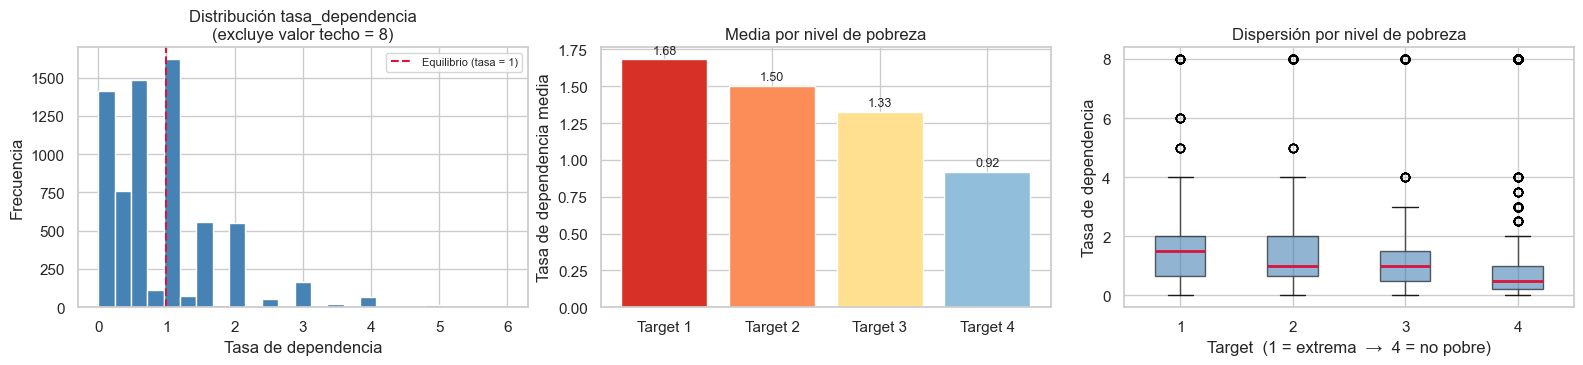


Shape: (7187, 110)


In [67]:
dep_raw = df["dependency"]
n_num = pd.to_numeric(dep_raw, errors="coerce").notna().sum()
n_yes = (dep_raw == "yes").sum()
n_no  = (dep_raw == "no").sum()
print(f"Composición de dependency: numérico={n_num:,} | yes={n_yes:,} | no={n_no:,}")

# Validación de la fórmula de reconstrucción contra valores numéricos disponibles
dep_num = pd.to_numeric(dep_raw, errors="coerce")
mask    = dep_num.notna()
d_val   = df[mask].copy()
d_val["dep_orig"] = dep_num[mask]

d_val["fA"] = ((d_val["hogar_nin"] + d_val["hogar_mayor"]) /
               (d_val["hogar_adul"] - d_val["hogar_mayor"]).replace(0, np.nan))
d_val["fB"] = ((d_val["hogar_nin"] + d_val["hogar_mayor"]) /
               d_val["hogar_adul"].replace(0, np.nan))

corr_A  = d_val["dep_orig"].corr(d_val["fA"])
corr_B  = d_val["dep_orig"].corr(d_val["fB"])
exact_A = (d_val["dep_orig"].round(4) == d_val["fA"].round(4)).sum()
exact_B = (d_val["dep_orig"].round(4) == d_val["fB"].round(4)).sum()
n_val   = mask.sum()

print(f"\nFórmula A = (nin+mayor)/(adul-mayor): corr={corr_A:.4f} | exactas={exact_A:,}/{n_val:,}")
print(f"Fórmula B = (nin+mayor)/adul         : corr={corr_B:.4f} | exactas={exact_B:,}/{n_val:,}")
del d_val

num_dep = df["hogar_nin"] + df["hogar_mayor"]
den_dep = df["hogar_adul"] - df["hogar_mayor"]
df["tasa_dependencia"] = np.where(den_dep == 0, 8.0, num_dep / den_dep)
df.drop(columns=["dependency"], inplace=True)

print("\nDistribución tasa_dependencia:")
print(df["tasa_dependencia"].describe().round(3).to_string())
print(f"\nTasa=0: {(df['tasa_dependencia'] == 0).sum():>5,} | "
      f"Tasa=8: {(df['tasa_dependencia'] == 8).sum():>5,} | "
      f"Tasa>1: {(df['tasa_dependencia'] > 1).sum():>5,}")
print("\nTasa media por Target:")
print(
    df.groupby("Target")["tasa_dependencia"].mean().round(3)
    .rename({1: "Pobreza extrema (1)", 2: "Pobreza moderada (2)",
             3: "Vulnerable (3)",      4: "No pobre (4)"})
    .to_string()
)

# Visualización diagnóstica
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(
    df[df["tasa_dependencia"] < 8]["tasa_dependencia"],
    bins=25, color="steelblue", edgecolor="white"
)
axes[0].axvline(1, color="crimson", linestyle="--", label="Equilibrio (tasa = 1)")
axes[0].set_title("Distribución tasa_dependencia\n(excluye valor techo = 8)")
axes[0].set_xlabel("Tasa de dependencia")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=8)

media_target = df.groupby("Target")["tasa_dependencia"].mean()
colores_pob  = ["#d73027", "#fc8d59", "#fee090", "#91bfdb"]
bars = axes[1].bar(
    [f"Target {i}" for i in media_target.index],
    media_target.values, color=colores_pob, edgecolor="white"
)
for bar, v in zip(bars, media_target.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                 f"{v:.2f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Media por nivel de pobreza")
axes[1].set_ylabel("Tasa de dependencia media")

df.boxplot(column="tasa_dependencia", by="Target", ax=axes[2],
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           medianprops=dict(color="crimson", linewidth=2))
axes[2].set_title("Dispersión por nivel de pobreza")
axes[2].set_xlabel("Target  (1 = extrema  →  4 = no pobre)")
axes[2].set_ylabel("Tasa de dependencia")
plt.suptitle("")
plt.tight_layout()
os.makedirs(DIR_VIZS, exist_ok=True)
plt.savefig(DIR_VIZS / "fig_tasa_dependencia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nShape: {df.shape}")

## 2.8 Variables adicionales

Se eliminan variables demográficos desagregados, parentescos, niveles educativos intermedios, estados civiles sin asociación a vulnerabilidad, dummies y demás variables sin relevancia.  
Preservados: `instlevel1` (sin educación), `estadocivil6` (viudo/a), `estadocivil7` (soltero/a).

In [68]:
drop_adicionales = [
    # a) Conteos demográficos desagregados
    "r4h1", "r4h2", "r4m1", "r4m2", "r4t1", "r4t2",
    # b) Parentesco — solo se conserva parentesco1
    "parentesco2", "parentesco3", "parentesco6",
    # c) Niveles educativos intermedios (instlevel1 PRESERVADA)
    "instlevel2", "instlevel3", "instlevel4", "instlevel5", "instlevel8",
    # d) Estado civil sin asociación a vulnerabilidad (estadocivil6/7 PRESERVADAS)
    "estadocivil1", "estadocivil2", "estadocivil3", "estadocivil4", "estadocivil5",
    # e) Dummies espejo (multicolinealidad perfecta con categoría de referencia)
    "area2", "epared3", "etecho3", "eviv3",
]

n_antes = df.shape[1]
df.drop(columns=[c for c in drop_adicionales if c in df.columns], inplace=True)
print(f"Eliminadas: {n_antes - df.shape[1]} variables | Shape: {df.shape}")

Eliminadas: 23 variables | Shape: (7187, 87)


## 3. Binarización del Target

Regla de mayoría a nivel de hogar; todos los miembros quedan con el mismo Target. Empate 50/50 → 1 (pobre), para minimizar falsos negativos.

In [69]:
_dist_target_orig = df["Target"].value_counts(normalize=True).mul(100).round(1).sort_index()

print("Distribución original (individuos):")
print(
    df["Target"].value_counts(normalize=True).mul(100).round(2)
    .rename({1: "Pobreza extrema (1)", 2: "Moderada (2)",
             3: "Vulnerable (3)",      4: "No pobre (4)"})
    .to_string()
)

df["Target_bin"] = (df["Target"] <= 2).astype(int)

target_por_hogar = (
    df.groupby("idhogar")["Target_bin"]
    .agg(lambda x: x.mode().max())  # en empate 0-1 elige 1
    .to_dict()
)
df["Target_final"] = df["idhogar"].map(target_por_hogar)

inconsistentes = (df.groupby("idhogar")["Target_bin"].nunique() > 1).sum()
cambiados = sum(
    1 for h in df["idhogar"].unique()
    if df.loc[df["idhogar"] == h, "Target_bin"].iloc[0] != target_por_hogar[h]
)
print(f"\nHogares con Target inconsistente entre miembros : {inconsistentes}")
print(f"Hogares cuyo Target cambia con la regla de mayoría: {cambiados}")

df.drop(columns=["Target", "Target_bin"], inplace=True)
df.rename(columns={"Target_final": "Target"}, inplace=True)

print("\nDistribución final (individuos):")
print(
    df["Target"].value_counts(normalize=True).mul(100).round(2)
    .rename({0: "No pobre (0)", 1: "Pobre (1)"})
    .to_string()
)

Distribución original (individuos):
Target
No pobre (4)           61.78
Moderada (2)           17.23
Vulnerable (3)         12.80
Pobreza extrema (1)     8.20

Hogares con Target inconsistente entre miembros : 28
Hogares cuyo Target cambia con la regla de mayoría: 10

Distribución final (individuos):
Target
No pobre (0)    74.66
Pobre (1)       25.34


## 4. Agregación al nivel de hogar (`idhogar`)

`first` para variables ya a nivel hogar, `mean` para proporciones y perfiles promedio, `max` para dummies y variables representativas del hogar.

In [70]:
agg_rules = {}

VARS_MAX  = {"v2a1", "rooms", "bedrooms", "overcrowding", "ed_jefe_final",
             "sin_jefe_educado", "paga_arriendo", "refrig", "computer",
             "television", "rez_esc"}
VARS_MEAN = {"escolari", "meaneduc", "age",
             "hogar_nin", "hogar_adul", "hogar_mayor", "hogar_total"}

for col in df.columns:
    if col in ("idhogar", "Target"):
        continue
    elif col == "female":
        agg_rules[col] = "mean"      # proporción de mujeres
    elif col == "tasa_dependencia":
        agg_rules[col] = "first"     # variable ya a nivel hogar
    elif col in VARS_MAX:
        agg_rules[col] = "max"
    elif col in VARS_MEAN:
        agg_rules[col] = "mean"
    else:
        agg_rules[col] = "max"       # dummies de infraestructura/ubicación

df_hogar = (
    df.groupby("idhogar")
    .agg({**agg_rules, "Target": "first"})
    .reset_index()
)

print(f"Individuos → hogares: {df.shape[0]:,} → {df_hogar.shape[0]:,}")
print(f"Tamaño medio de hogar: {df.shape[0] / df_hogar.shape[0]:.1f} personas")
print(f"Shape: {df_hogar.shape}")
print("\nDistribución del Target en hogares:")
print(
    df_hogar["Target"].value_counts(normalize=True).mul(100).round(2)
    .rename({0: "No pobre (0)", 1: "Pobre (1)"})
    .to_string()
)

Individuos → hogares: 7,187 → 2,241
Tamaño medio de hogar: 3.2 personas
Shape: (2241, 87)

Distribución del Target en hogares:
Target
No pobre (0)    77.06
Pobre (1)       22.94


## 5. Diagnóstico de multicolinealidad (VIF)

VIF = ∞ indica multicolinealidad perfecta; VIF > 10 indica alta redundancia. Este diagnóstico guía las eliminaciones del paso 6.

In [71]:
X_vif = df_hogar.select_dtypes(include=[np.number]).drop(columns=["Target"], errors="ignore")

vif_data = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(len(X_vif.columns))
    ]
})

n_inf  = np.isinf(vif_data["VIF"]).sum()
n_alto = (vif_data["VIF"] > 10).sum()
print(f"VIF = ∞ (multicolinealidad perfecta): {n_inf}")
print(f"VIF > 10 (alta redundancia): {n_alto}")

if n_inf > 0:
    print("\nVariables con VIF infinito:")
    for v in vif_data[np.isinf(vif_data["VIF"])]["variable"].tolist():
        print(f"  • {v}")

d:\Wuu\Universidad\2026-10\Consultoría Económica con IA\Repositorios\Sandbox_HE2_DavidRodriguez\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
d:\Wuu\Universidad\2026-10\Consultoría Económica con IA\Repositorios\Sandbox_HE2_DavidRodriguez\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
d:\Wuu\Universidad\2026-10\Consultoría Económica con IA\Repositorios\Sandbox_HE2_DavidRodriguez\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


VIF = ∞ (multicolinealidad perfecta): 21
VIF > 10 (alta redundancia): 37

Variables con VIF infinito:
  • abastaguadentro
  • abastaguafuera
  • abastaguano
  • hogar_nin
  • hogar_adul
  • hogar_total
  • edjefe
  • edjefa
  • tipovivi1
  • tipovivi2
  • tipovivi3
  • tipovivi4
  • tipovivi5
  • lugar1
  • lugar2
  • lugar3
  • lugar4
  • lugar5
  • lugar6
  • paga_arriendo
  • ed_jefe_final


## 6a. Resolución de multicolinealidades perfectas

Se elimina una variable de cada grupo de dummies que suman exactamente 1 (trampa de variables ficticias) y las redundancias confirmadas entre activos.

In [72]:
drop_post_vif = [
    # Composición del hogar
    "hogar_total",    # = hogar_nin + hogar_adul → VIF = ∞
    "parentesco1",    # constante = 1 tras agregación
    # Educación del jefe (consolidadas en ed_jefe_final)
    "edjefe", "edjefa",
    # Trampa de dummies: región (referencia = Huetar Norte)
    "lugar6",
    # Trampa de dummies: acceso a agua (referencia = agua dentro)
    "abastaguadentro",
    # Trampa de dummies: tenencia de vivienda
    "tipovivi1",   # referencia: propia y pagada
    "tipovivi3",   # arrendada (rompe ciclo VIF = ∞)
    # Redundancias de activos
    "paga_arriendo",  # redundante con v2a1 (v2a1>0 ↔ paga_arriendo=1)
    "v18q",           # redundante con v18q1
    "public",         # electricidad pública: redundante con el grupo
    # Energía para cocinar (alta correlación con NSE)
    "energcocinar2", "energcocinar3",
    # Identificador individual
    "Id",
]

df_model = df_hogar.drop(columns=[c for c in drop_post_vif if c in df_hogar.columns])
print(f"Eliminadas: {len([c for c in drop_post_vif if c in df_hogar.columns])} | Shape: {df_model.shape}")

# Verificación post-corrección
X_check = df_model.select_dtypes(include=[np.number]).drop(columns=["Target"], errors="ignore")
vif_check = pd.DataFrame({
    "variable": X_check.columns,
    "VIF": [variance_inflation_factor(X_check.values, i) for i in range(len(X_check.columns))]
})
n_inf_post = np.isinf(vif_check["VIF"]).sum()
print(f"\nVIF infinitos restantes: {n_inf_post}")
if n_inf_post == 0:
    print("\nTop 5 VIF tras corrección:")
    print(vif_check.sort_values("VIF", ascending=False).head(5).to_string(index=False))

Eliminadas: 14 | Shape: (2241, 73)


d:\Wuu\Universidad\2026-10\Consultoría Económica con IA\Repositorios\Sandbox_HE2_DavidRodriguez\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss



VIF infinitos restantes: 0

Top 5 VIF tras corrección:
   variable        VIF
 pisomoscer 338.339333
       v14a 256.534770
 sanitario3 226.321176
  elimbasu1 214.872226
pisocemento 109.030958


## 6b. Reducción de dimensionalidad post-agregación

Se eliminan variables que pierden poder explicativo al colapsar al nivel hogar o quedan redundadas por versiones más parsimoniosas.  
> `pareddes` y `pisonotiene` se **preservan**: en la metodología NBI de Costa Rica, los materiales objetivos son el criterio oficial (no la evaluación subjetiva del entrevistador).

In [73]:
drop_post_agr = [
    "v14a",          # redundante con tipos específicos de sanitario
    "mobilephone",   # casi cero varianza; qmobilephone (intensidad) es más informativo
    "rooms",         # redundante con bedrooms para NBI
    "rez_esc",       # sustituido por tiene_retraso (más robusto tras imputación)
    "hacdor",        # capturado por overcrowding
    "hacapo",        # ídem
    "ed_jefe_final", # colineal con meaneduc (agrega información de todos los adultos)
    # pareddes    → PRESERVADA (material objetivo, indicador NBI)
    # pisonotiene → PRESERVADA (material objetivo, indicador NBI)
]

n_antes_6b = df_model.shape[1]
df_model.drop(columns=[c for c in drop_post_agr if c in df_model.columns], inplace=True)
print(f"Eliminadas: {n_antes_6b - df_model.shape[1]} | Shape: {df_model.shape}")

Eliminadas: 7 | Shape: (2241, 66)


## 7. Renombrado de variables a nombres descriptivos

In [74]:
diccionario_nombres = {
    # Vivienda y activos
    "v2a1":         "Monto_Alquiler",
    "v18q1":        "Cantidad_Tablets",
    "refrig":       "Tiene_Nevera",
    "computer":     "Tiene_Computador",
    "television":   "Tiene_TV",
    "qmobilephone": "Cant_Celulares",
    "bedrooms":     "Total_Dormitorios",
    "overcrowding": "Personas_por_Cuarto",
    # Educación
    "escolari":         "Promedio_Anos_Escolaridad",
    "meaneduc":         "Promedio_Educ_Adultos",
    "instlevel1":       "Sin_Educacion",
    "instlevel6":       "Educ_Tecnica_Incompleta",
    "instlevel7":       "Educ_Tecnica_Completa",
    "instlevel9":       "Educ_Postgrado",
    "sin_jefe_educado": "Hogar_sin_Jefe_Educado",
    "tiene_retraso":    "Hogar_con_Rezago_Escolar",
    # Estado civil
    "estadocivil6": "Jefe_Viudo",
    "estadocivil7": "Jefe_Soltero",
    # Materiales: paredes
    "paredblolad": "Pared_Bloque_Ladrillo",
    "paredzocalo": "Pared_Zocalo",
    "paredpreb":   "Pared_Prefabricado",
    "pareddes":    "Pared_Desecho",
    "paredmad":    "Pared_Madera",
    # Materiales: piso
    "pisomoscer":  "Piso_Mosaico_Ceramica",
    "pisocemento": "Piso_Cemento",
    "pisonotiene": "Piso_Tierra",
    "pisomadera":  "Piso_Madera",
    # Materiales: techo
    "techozinc":  "Techo_Zinc",
    "cielorazo":  "Tiene_Cielorazo",
    # Estado de infraestructura (evaluación subjetiva del entrevistador)
    "epared1": "Pared_Mala",    "epared2": "Pared_Regular",
    "etecho1": "Techo_Malo",    "etecho2": "Techo_Regular",
    "eviv1":   "Piso_Malo",     "eviv2":   "Piso_Regular",
    # Servicios básicos
    "abastaguafuera": "Agua_Fuera_Vivienda",
    "abastaguano":    "Sin_Abasto_Agua",
    "noelec":         "Sin_Electricidad",
    "coopele":        "Electricidad_Cooperativa",
    "sanitario1":     "Sin_Inodoro",
    "sanitario2":     "Inodoro_Alcantarillado",
    "sanitario3":     "Inodoro_Septico",
    "sanitario5":     "Inodoro_Letrina",
    "energcocinar4":  "Cocina_Carbon_Lena",
    "elimbasu1":      "Basura_Camion",
    "elimbasu2":      "Basura_Enterrada",
    "elimbasu3":      "Basura_Quemada",
    "elimbasu5":      "Basura_Rio_Creek",
    # Demografía
    "dis":          "Tiene_Discapacitado",
    "female":       "Proporcion_Mujeres",
    "hogar_nin":    "Cant_Ninos",
    "hogar_adul":   "Cant_Adultos",
    "hogar_mayor":  "Cant_Adultos_Mayores",
    "age":          "Edad_Promedio",
    "tasa_dependencia": "Tasa_Dependencia",
    # Tenencia y ubicación
    "tipovivi2": "Casa_Propia_Pagando",
    "tipovivi4": "Casa_Precario",
    "tipovivi5": "Casa_Prestada_Asignada",
    "lugar1":    "Region_Central",
    "lugar2":    "Region_Chorotega",
    "lugar3":    "Region_Pacifico_Central",
    "lugar4":    "Region_Brunca",
    "lugar5":    "Region_Huetar_Atlantica",
    "area1":     "Zona_Urbana",
}

df_model.rename(columns=diccionario_nombres, inplace=True)
print(f"Variables en el dataset final: {len(df_model.columns)} | Shape: {df_model.shape}")
print("\nColumnas finales:")
for i, col in enumerate(df_model.columns, 1):
    marker = " ←" if col in ("Sin_Educacion", "Jefe_Viudo", "Jefe_Soltero",
                              "Tasa_Dependencia") else ""
    print(f"  {i:3d}.  {col}{marker}")

Variables en el dataset final: 66 | Shape: (2241, 66)

Columnas finales:
    1.  idhogar
    2.  Monto_Alquiler
    3.  Tiene_Nevera
    4.  Cantidad_Tablets
    5.  Promedio_Anos_Escolaridad
    6.  Pared_Bloque_Ladrillo
    7.  Pared_Zocalo
    8.  Pared_Prefabricado
    9.  Pared_Desecho
   10.  Pared_Madera
   11.  Piso_Mosaico_Ceramica
   12.  Piso_Cemento
   13.  Piso_Tierra
   14.  Piso_Madera
   15.  Techo_Zinc
   16.  Tiene_Cielorazo
   17.  Agua_Fuera_Vivienda
   18.  Sin_Abasto_Agua
   19.  Sin_Electricidad
   20.  Electricidad_Cooperativa
   21.  Sin_Inodoro
   22.  Inodoro_Alcantarillado
   23.  Inodoro_Septico
   24.  Inodoro_Letrina
   25.  Cocina_Carbon_Lena
   26.  Basura_Camion
   27.  Basura_Enterrada
   28.  Basura_Quemada
   29.  Basura_Rio_Creek
   30.  Pared_Mala
   31.  Pared_Regular
   32.  Techo_Malo
   33.  Techo_Regular
   34.  Piso_Malo
   35.  Piso_Regular
   36.  Tiene_Discapacitado
   37.  Proporcion_Mujeres
   38.  Jefe_Viudo ←
   39.  Jefe_Soltero ←
  

## 8. Feature engineering — 4 índices compuestos

| Índice | Dirección | Componentes |
|---|---|---|
| `Indice_Activos_Tech` | ↑ menos pobre | Suma de activos duraderos (proxy ingreso permanente) |
| `Privacion_Servicios_Basicos` | ↑ más pobre | Carencias NBI: electricidad, agua, saneamiento, combustible, basura |
| `Calidad_Materiales_Vivienda` | ↑ más pobre | Materiales precarios (+) vs. nobles (−); excluye Techo_Zinc |
| `Hacinamiento_Severo` | dummy | > 3 personas/cuarto (umbral latinoamericano) |

Indice_Activos_Tech         → rango 0–16,  media 4.02
Privacion_Servicios_Basicos → rango 0–4,  media 0.21
Calidad_Materiales_Vivienda → rango -3–2,  media -1.95
Hacinamiento_Severo         → 45 hogares (2.0%)

Shape tras feature engineering: (2241, 52)


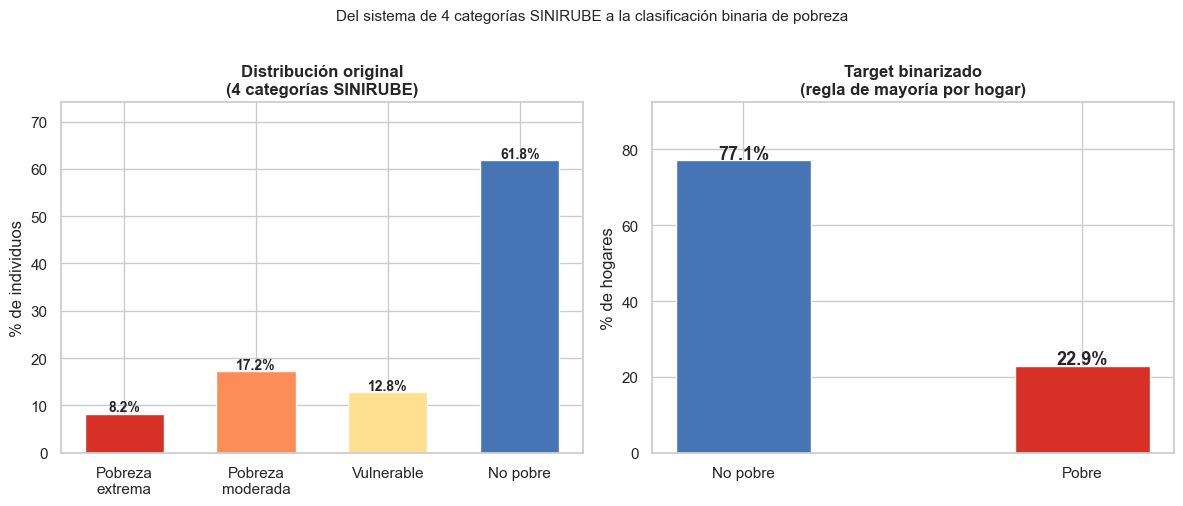

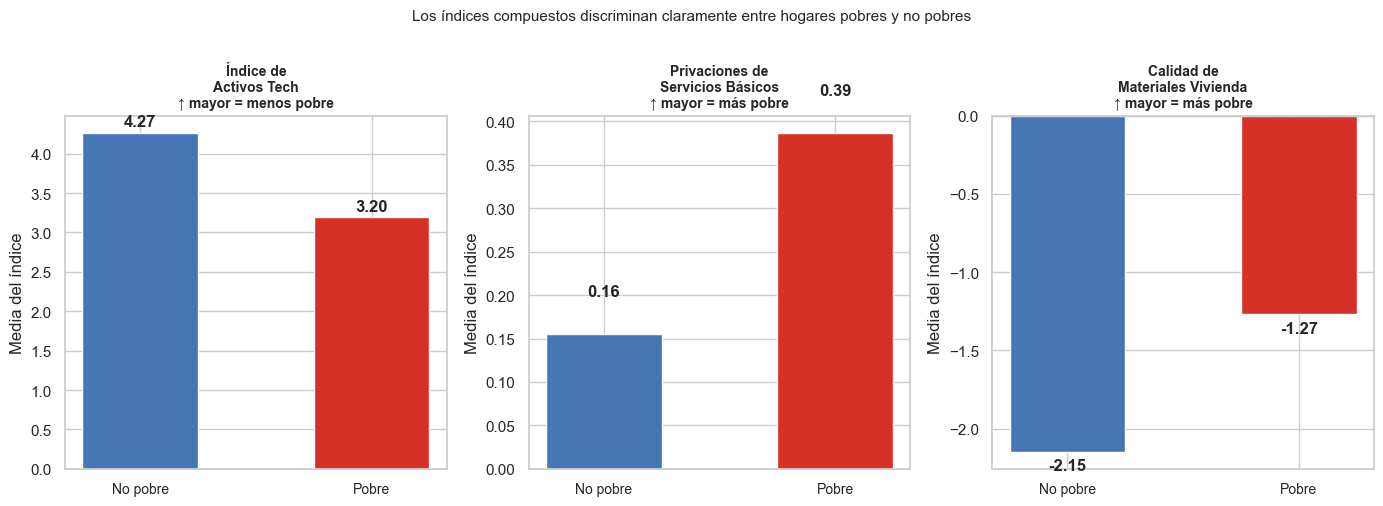

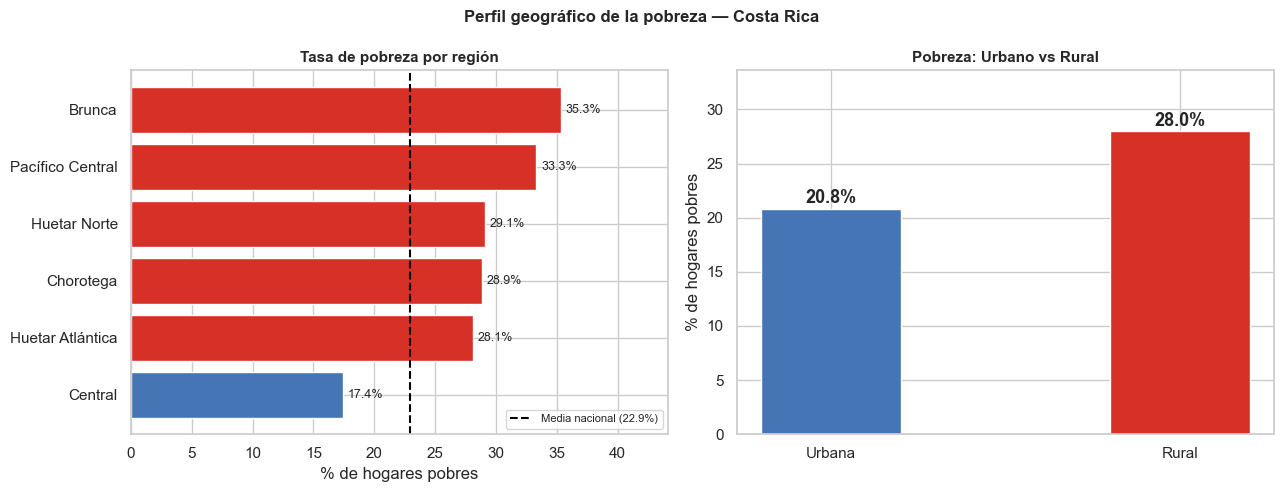


3 figuras guardadas en: D:\Wuu\Universidad\2026-10\Consultoría Económica con IA\Repositorios\Sandbox_HE2_DavidRodriguez\Taller 1\Punto 1. Clasificacion para Focalización de Programas Sociales\Visualizaciones


In [75]:
# 8.1 Índice de activos tecnológicos
df_model["Indice_Activos_Tech"] = (
    df_model["Tiene_Nevera"]
    + df_model["Tiene_Computador"]
    + df_model["Tiene_TV"]
    + df_model["Cant_Celulares"]
    + df_model["Cantidad_Tablets"]
)
print(f"Indice_Activos_Tech         → rango {df_model['Indice_Activos_Tech'].min():.0f}–{df_model['Indice_Activos_Tech'].max():.0f},  media {df_model['Indice_Activos_Tech'].mean():.2f}")

# 8.2 Índice de privaciones de servicios básicos (NBI)
_carencia_agua   = (
    (df_model["Sin_Abasto_Agua"] == 1) | (df_model["Agua_Fuera_Vivienda"] == 1)
).astype(int)
_carencia_basura = (
    (df_model["Basura_Enterrada"] == 1)
    | (df_model["Basura_Quemada"] == 1)
    | (df_model["Basura_Rio_Creek"] == 1)
).astype(int)
df_model["Privacion_Servicios_Basicos"] = (
    (df_model["Sin_Electricidad"] == 1).astype(int)
    + _carencia_agua
    + (df_model["Sin_Inodoro"] == 1).astype(int)
    + (df_model["Cocina_Carbon_Lena"] == 1).astype(int)
    + _carencia_basura
)
print(f"Privacion_Servicios_Basicos → rango {df_model['Privacion_Servicios_Basicos'].min():.0f}–{df_model['Privacion_Servicios_Basicos'].max():.0f},  media {df_model['Privacion_Servicios_Basicos'].mean():.2f}")

# 8.3 Índice de calidad de materiales (Techo_Zinc excluido: no discrimina pobreza)
df_model["Calidad_Materiales_Vivienda"] = (
    df_model["Pared_Desecho"]
    + df_model["Piso_Tierra"]
    - df_model["Piso_Mosaico_Ceramica"]
    - df_model["Tiene_Cielorazo"]
    - df_model["Pared_Bloque_Ladrillo"]
)
print(f"Calidad_Materiales_Vivienda → rango {df_model['Calidad_Materiales_Vivienda'].min():.0f}–{df_model['Calidad_Materiales_Vivienda'].max():.0f},  media {df_model['Calidad_Materiales_Vivienda'].mean():.2f}")

# 8.4 Hacinamiento severo (umbral: 3 personas/cuarto)
df_model["Hacinamiento_Severo"] = (df_model["Personas_por_Cuarto"] > 3).astype(int)
print(f"Hacinamiento_Severo         → {df_model['Hacinamiento_Severo'].sum()} hogares ({df_model['Hacinamiento_Severo'].mean()*100:.1f}%)")

# Eliminación de variables componentes
drop_componentes = [
    "Tiene_Nevera", "Tiene_Computador", "Tiene_TV", "Cant_Celulares", "Cantidad_Tablets",
    "Sin_Electricidad", "Sin_Abasto_Agua", "Agua_Fuera_Vivienda",
    "Sin_Inodoro", "Cocina_Carbon_Lena",
    "Basura_Enterrada", "Basura_Quemada", "Basura_Rio_Creek",
    "Pared_Desecho", "Piso_Tierra",
    "Piso_Mosaico_Ceramica", "Tiene_Cielorazo", "Pared_Bloque_Ladrillo",
]
df_model.drop(columns=[c for c in drop_componentes if c in df_model.columns], inplace=True)
print(f"\nShape tras feature engineering: {df_model.shape}")

# ── Visualizaciones diagnósticas ──────────────────────────────────────────────
os.makedirs(DIR_VIZS, exist_ok=True)
_POBRE    = "#d73027"
_NO_POBRE = "#4575b4"

# Fig 1: Distribución del Target (original → binarizado)
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
labels_orig = ["Pobreza\nextrema", "Pobreza\nmoderada", "Vulnerable", "No pobre"]
colors_orig = [_POBRE, "#fc8d59", "#fee090", _NO_POBRE]
bars_o = ax1[0].bar(labels_orig, _dist_target_orig.values,
                    color=colors_orig, edgecolor="white", width=0.6)
for bar, val in zip(bars_o, _dist_target_orig.values):
    ax1[0].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax1[0].set_title("Distribución original\n(4 categorías SINIRUBE)", fontsize=12, fontweight="bold")
ax1[0].set_ylabel("% de individuos")
ax1[0].set_ylim(0, _dist_target_orig.max() * 1.2)

_dist_bin = (df_model["Target"].value_counts(normalize=True)
             .mul(100).round(1)
             .rename({0: "No pobre", 1: "Pobre"})
             .sort_index())
bars_b = ax1[1].bar(_dist_bin.index, _dist_bin.values,
                    color=[_NO_POBRE, _POBRE], edgecolor="white", width=0.4)
for bar, val in zip(bars_b, _dist_bin.values):
    ax1[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold")
ax1[1].set_title("Target binarizado\n(regla de mayoría por hogar)", fontsize=12, fontweight="bold")
ax1[1].set_ylabel("% de hogares")
ax1[1].set_ylim(0, _dist_bin.max() * 1.2)
fig1.suptitle("Del sistema de 4 categorías SINIRUBE a la clasificación binaria de pobreza",
              fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(DIR_VIZS / "fig1_distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 2: Índices compuestos por pobreza
fig2, ax2 = plt.subplots(1, 3, figsize=(14, 5))
_indices_viz = [
    ("Indice_Activos_Tech",         "Índice de\nActivos Tech",          "↑ mayor = menos pobre"),
    ("Privacion_Servicios_Basicos", "Privaciones de\nServicios Básicos","↑ mayor = más pobre"),
    ("Calidad_Materiales_Vivienda", "Calidad de\nMateriales Vivienda",  "↑ mayor = más pobre"),
]
for ax, (var, titulo, nota) in zip(ax2, _indices_viz):
    medias = df_model.groupby("Target")[var].mean()
    ax.bar([0, 1], medias.values, color=[_NO_POBRE, _POBRE], edgecolor="white", width=0.5)
    for x, val in enumerate(medias.values):
        offset = 0.04 if val >= 0 else -0.04
        va     = "bottom" if val >= 0 else "top"
        ax.text(x, val + offset, f"{val:.2f}",
                ha="center", va=va, fontsize=12, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No pobre", "Pobre"], fontsize=10)
    ax.set_title(f"{titulo}\n{nota}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Media del índice")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
fig2.suptitle("Los índices compuestos discriminan claramente entre hogares pobres y no pobres",
              fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(DIR_VIZS / "fig2_indices_por_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 3: Perfil geográfico
fig3, ax3 = plt.subplots(1, 2, figsize=(13, 5))
_mapa_reg = {
    "Region_Central":          "Central",
    "Region_Chorotega":        "Chorotega",
    "Region_Pacifico_Central": "Pacífico Central",
    "Region_Brunca":           "Brunca",
    "Region_Huetar_Atlantica": "Huetar Atlántica",
}
_tasa_reg = {}
_cols_reg = [c for c in _mapa_reg if c in df_model.columns]
for col, nombre in _mapa_reg.items():
    if col in df_model.columns:
        sub = df_model[df_model[col] == 1]
        if len(sub) > 0:
            _tasa_reg[nombre] = sub["Target"].mean() * 100
_mask_norte = df_model[_cols_reg].sum(axis=1) == 0
if _mask_norte.sum() > 0:
    _tasa_reg["Huetar Norte"] = df_model[_mask_norte]["Target"].mean() * 100

_tasa_s    = pd.Series(_tasa_reg).sort_values()
_media_nac = df_model["Target"].mean() * 100
_color_reg = [_POBRE if v > _media_nac else _NO_POBRE for v in _tasa_s.values]

ax3[0].barh(_tasa_s.index, _tasa_s.values, color=_color_reg, edgecolor="white")
ax3[0].axvline(_media_nac, color="black", linestyle="--", linewidth=1.5,
               label=f"Media nacional ({_media_nac:.1f}%)")
for i, val in enumerate(_tasa_s.values):
    ax3[0].text(val + 0.4, i, f"{val:.1f}%", va="center", fontsize=9)
ax3[0].set_title("Tasa de pobreza por región", fontsize=11, fontweight="bold")
ax3[0].set_xlabel("% de hogares pobres")
ax3[0].legend(fontsize=8)
ax3[0].set_xlim(0, _tasa_s.max() * 1.25)

if "Zona_Urbana" in df_model.columns:
    _t_urb = df_model[df_model["Zona_Urbana"] == 1]["Target"].mean() * 100
    _t_rur = df_model[df_model["Zona_Urbana"] == 0]["Target"].mean() * 100
    _areas  = ["Urbana", "Rural"]
    _tasas  = [_t_urb, _t_rur]
    _c_area = [_NO_POBRE if _t_urb < _t_rur else _POBRE,
               _POBRE    if _t_rur > _t_urb else _NO_POBRE]
    bars_a = ax3[1].bar(_areas, _tasas, color=_c_area, edgecolor="white", width=0.4)
    for bar, val in zip(bars_a, _tasas):
        ax3[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                    f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold")
    ax3[1].set_title("Pobreza: Urbano vs Rural", fontsize=11, fontweight="bold")
    ax3[1].set_ylabel("% de hogares pobres")
    ax3[1].set_ylim(0, max(_tasas) * 1.2)

fig3.suptitle("Perfil geográfico de la pobreza — Costa Rica", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(DIR_VIZS / "fig3_perfil_geografico.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n3 figuras guardadas en: {DIR_VIZS}")

## 9. Exportación

Dataset limpio exportado sin estandarizar. El `StandardScaler` se ajusta en el notebook de modelamiento para evitar data leakage.

In [76]:
os.makedirs(DIR_DATOS, exist_ok=True)

output_path = DIR_DATOS / "train_cleaned_hogar.csv"
df_model.to_csv(output_path, index=False)

print(f"Archivo guardado : {output_path}")
print(f"Filas            : {df_model.shape[0]:,}")
print(f"Columnas         : {df_model.shape[1]}")
print("\nDistribución final del Target:")
print(
    df_model["Target"].value_counts(normalize=True).mul(100).round(2)
    .rename({0: "No pobre (0)", 1: "Pobre (1)"})
    .to_string()
)
print("\nPipeline completado exitosamente.")

Archivo guardado : D:\Wuu\Universidad\2026-10\Consultoría Económica con IA\Repositorios\Sandbox_HE2_DavidRodriguez\Taller 1\Punto 1. Clasificacion para Focalización de Programas Sociales\Datos\train_cleaned_hogar.csv
Filas            : 2,241
Columnas         : 52

Distribución final del Target:
Target
No pobre (0)    77.06
Pobre (1)       22.94

Pipeline completado exitosamente.
